In [1]:
def get_obj_values(run_gen_text_content: str):
    output_list = []
    for solution_text in run_gen_text_content.split("--------------")[:-1]:
        run_gen_solution_text_content = solution_text
        output_list.append([float(item[item.find(': ')+2:]) for item in run_gen_solution_text_content[run_gen_solution_text_content.find(']')+1:].split('\n')[1:-1]])
    return output_list

In [2]:
import os

def load_runs_and_gens_as_dict(directory="."):
    data = {}
    run_index = 0

    while True:
        run_key = f"run_{run_index}"
        gen_index = 0
        run_data = []

        while True:
            filename = f"{run_key}_gen_{gen_index}.txt"
            filepath = os.path.join(directory, filename)

            if os.path.isfile(filepath):
                with open(filepath, 'r', encoding='utf-8') as f:
                    run_data.append(get_obj_values(f.read()))
                gen_index += 1
            else:
                break  # No more gens for this run

        if run_data:
            data[run_key] = run_data
            run_index += 1
        else:
            break  # No more runs

    return data


In [3]:
run_gen_dict = load_runs_and_gens_as_dict()
run_gen_dict

{'run_0': [[[0.62, 0.2, 0.8],
   [0.59, 0.23, 0.76],
   [0.49, 0.24, 0.75],
   [0.48, 0.32, 0.77],
   [0.54, 0.31, 0.69],
   [0.54, 0.27, 0.71],
   [0.67, 0.17, 0.84],
   [0.66, 0.18, 0.86],
   [0.55, 0.23, 0.81],
   [0.55, 0.24, 0.72]],
  [[0.49, 0.24, 0.75],
   [0.48, 0.32, 0.77],
   [0.54, 0.31, 0.69],
   [0.54, 0.27, 0.71],
   [0.67, 0.17, 0.84],
   [0.66, 0.18, 0.86],
   [0.55, 0.24, 0.72],
   [0.52, 0.23, 0.75],
   [0.63, 0.19, 0.8],
   [0.66, 0.27, 0.7],
   [0.54, 0.25, 0.74],
   [0.63, 0.21, 0.76],
   [0.62, 0.21, 0.79],
   [0.49, 0.27, 0.74],
   [0.59, 0.2, 0.8],
   [0.51, 0.23, 0.76],
   [0.62, 0.19, 0.85],
   [0.61, 0.22, 0.78]],
  [[0.49, 0.24, 0.75],
   [0.48, 0.32, 0.77],
   [0.54, 0.31, 0.69],
   [0.54, 0.27, 0.71],
   [0.67, 0.17, 0.84],
   [0.55, 0.24, 0.72],
   [0.52, 0.23, 0.75],
   [0.63, 0.19, 0.8],
   [0.63, 0.21, 0.76],
   [0.49, 0.27, 0.74],
   [0.51, 0.23, 0.76],
   [0.62, 0.19, 0.85],
   [0.5, 0.25, 0.73],
   [0.55, 0.2, 0.9],
   [0.58, 0.21, 0.77],
   [0.52, 

In [4]:
def dict_to_data_for_visualization(run_gen_values_dict: dict):
    all = {}
    for key,run in run_gen_values_dict.items():
        all[key] = {}
        for generation in run:
            all[key][run.index(generation)] = {}
            min_obj1 = min([solution[0] for solution in generation])
            min_obj2 = min([solution[1] for solution in generation])
            min_obj3 = min([solution[2] for solution in generation])
            avg_obj1 = sum([solution[0] for solution in generation]) / len(generation)
            avg_obj2 = sum([solution[1] for solution in generation]) / len(generation)
            avg_obj3 = sum([solution[2] for solution in generation]) / len(generation)

            all[key][run.index(generation)]["min_obj1"] = min_obj1
            all[key][run.index(generation)]["min_obj2"] = min_obj2
            all[key][run.index(generation)]["min_obj3"] = min_obj3

            all[key][run.index(generation)]["avg_obj1"] = avg_obj1
            all[key][run.index(generation)]["avg_obj2"] = avg_obj2
            all[key][run.index(generation)]["avg_obj3"] = avg_obj3

            print(f"For the run index {key} and generation index {run.index(generation)}:")
            print(f"MIN of objective index 0: {min_obj1}")
            print(f"MIN of objective index 1: {min_obj2}")
            print(f"MIN of objective index 2: {min_obj3}")
            print(f"AVG of objective index 0: {avg_obj1}")
            print(f"AVG of objective index 1: {avg_obj2}")
            print(f"AVG of objective index 2: {avg_obj3}")
            print("--------------")
    return all


visualization_data = dict_to_data_for_visualization(run_gen_dict)
visualization_data

For the run index run_0 and generation index 0:
MIN of objective index 0: 0.48
MIN of objective index 1: 0.17
MIN of objective index 2: 0.69
AVG of objective index 0: 0.5690000000000001
AVG of objective index 1: 0.23900000000000002
AVG of objective index 2: 0.771
--------------
For the run index run_0 and generation index 1:
MIN of objective index 0: 0.48
MIN of objective index 1: 0.17
MIN of objective index 2: 0.69
AVG of objective index 0: 0.575
AVG of objective index 1: 0.23333333333333334
AVG of objective index 2: 0.7672222222222222
--------------
For the run index run_0 and generation index 2:
MIN of objective index 0: 0.47
MIN of objective index 1: 0.17
MIN of objective index 2: 0.69
AVG of objective index 0: 0.5542857142857143
AVG of objective index 1: 0.23666666666666666
AVG of objective index 2: 0.7685714285714286
--------------
For the run index run_0 and generation index 3:
MIN of objective index 0: 0.44
MIN of objective index 1: 0.17
MIN of objective index 2: 0.69
AVG of ob

{'run_0': {0: {'min_obj1': 0.48,
   'min_obj2': 0.17,
   'min_obj3': 0.69,
   'avg_obj1': 0.5690000000000001,
   'avg_obj2': 0.23900000000000002,
   'avg_obj3': 0.771},
  1: {'min_obj1': 0.48,
   'min_obj2': 0.17,
   'min_obj3': 0.69,
   'avg_obj1': 0.575,
   'avg_obj2': 0.23333333333333334,
   'avg_obj3': 0.7672222222222222},
  2: {'min_obj1': 0.47,
   'min_obj2': 0.17,
   'min_obj3': 0.69,
   'avg_obj1': 0.5542857142857143,
   'avg_obj2': 0.23666666666666666,
   'avg_obj3': 0.7685714285714286},
  3: {'min_obj1': 0.44,
   'min_obj2': 0.17,
   'min_obj3': 0.69,
   'avg_obj1': 0.5289473684210527,
   'avg_obj2': 0.24105263157894738,
   'avg_obj3': 0.741578947368421},
  4: {'min_obj1': 0.34,
   'min_obj2': 0.15,
   'min_obj3': 0.68,
   'avg_obj1': 0.5178260869565218,
   'avg_obj2': 0.24173913043478262,
   'avg_obj3': 0.7404347826086957}},
 'run_1': {0: {'min_obj1': 0.5,
   'min_obj2': 0.37,
   'min_obj3': 0.58,
   'avg_obj1': 0.5790909090909091,
   'avg_obj2': 0.4227272727272728,
   'avg_

{0: {'min_obj1': 0.48, 'min_obj2': 0.17, 'min_obj3': 0.69, 'avg_obj1': 0.5690000000000001, 'avg_obj2': 0.23900000000000002, 'avg_obj3': 0.771}, 1: {'min_obj1': 0.48, 'min_obj2': 0.17, 'min_obj3': 0.69, 'avg_obj1': 0.575, 'avg_obj2': 0.23333333333333334, 'avg_obj3': 0.7672222222222222}, 2: {'min_obj1': 0.47, 'min_obj2': 0.17, 'min_obj3': 0.69, 'avg_obj1': 0.5542857142857143, 'avg_obj2': 0.23666666666666666, 'avg_obj3': 0.7685714285714286}, 3: {'min_obj1': 0.44, 'min_obj2': 0.17, 'min_obj3': 0.69, 'avg_obj1': 0.5289473684210527, 'avg_obj2': 0.24105263157894738, 'avg_obj3': 0.741578947368421}, 4: {'min_obj1': 0.34, 'min_obj2': 0.15, 'min_obj3': 0.68, 'avg_obj1': 0.5178260869565218, 'avg_obj2': 0.24173913043478262, 'avg_obj3': 0.7404347826086957}}


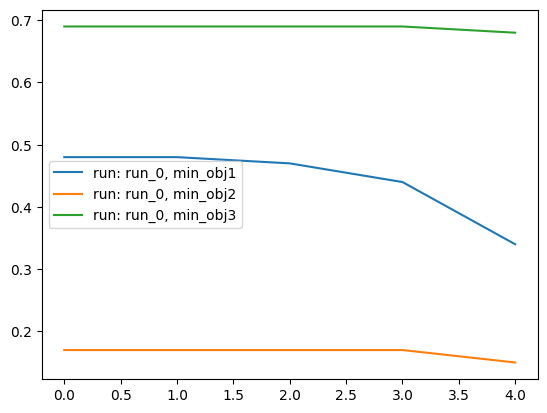

{0: {'min_obj1': 0.5, 'min_obj2': 0.37, 'min_obj3': 0.58, 'avg_obj1': 0.5790909090909091, 'avg_obj2': 0.4227272727272728, 'avg_obj3': 0.6645454545454546}, 1: {'min_obj1': 0.5, 'min_obj2': 0.34, 'min_obj3': 0.58, 'avg_obj1': 0.5821052631578948, 'avg_obj2': 0.4142105263157895, 'avg_obj3': 0.6552631578947368}, 2: {'min_obj1': 0.5, 'min_obj2': 0.34, 'min_obj3': 0.58, 'avg_obj1': 0.5736363636363637, 'avg_obj2': 0.4163636363636364, 'avg_obj3': 0.6554545454545454}, 3: {'min_obj1': 0.48, 'min_obj2': 0.34, 'min_obj3': 0.57, 'avg_obj1': 0.5735714285714285, 'avg_obj2': 0.41571428571428576, 'avg_obj3': 0.6542857142857142}, 4: {'min_obj1': 0.48, 'min_obj2': 0.34, 'min_obj3': 0.57, 'avg_obj1': 0.5720689655172414, 'avg_obj2': 0.406551724137931, 'avg_obj3': 0.6448275862068965}}


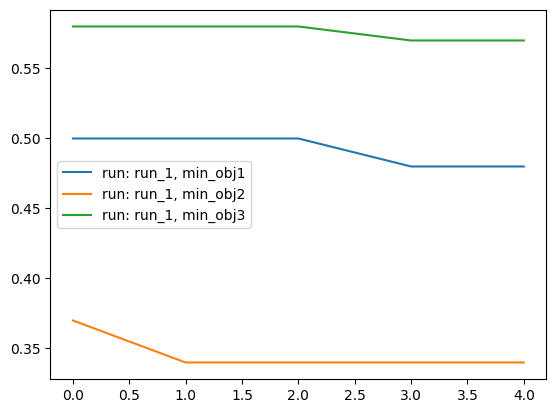

{0: {'min_obj1': 0.53, 'min_obj2': 0.28, 'min_obj3': 0.51, 'avg_obj1': 0.595, 'avg_obj2': 0.37125, 'avg_obj3': 0.63125}, 1: {'min_obj1': 0.53, 'min_obj2': 0.28, 'min_obj3': 0.48, 'avg_obj1': 0.6157142857142858, 'avg_obj2': 0.36428571428571427, 'avg_obj3': 0.6378571428571428}, 2: {'min_obj1': 0.52, 'min_obj2': 0.26, 'min_obj3': 0.48, 'avg_obj1': 0.6122727272727273, 'avg_obj2': 0.3709090909090909, 'avg_obj3': 0.615}, 3: {'min_obj1': 0.51, 'min_obj2': 0.22, 'min_obj3': 0.46, 'avg_obj1': 0.6062962962962963, 'avg_obj2': 0.36333333333333334, 'avg_obj3': 0.6251851851851852}, 4: {'min_obj1': 0.47, 'min_obj2': 0.22, 'min_obj3': 0.46, 'avg_obj1': 0.6086666666666667, 'avg_obj2': 0.3496666666666667, 'avg_obj3': 0.6329999999999999}}


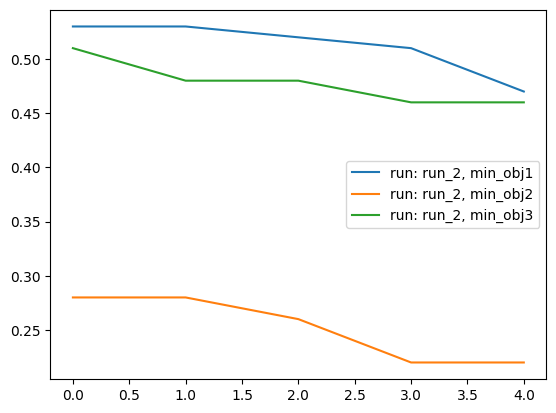

{0: {'min_obj1': 0.57, 'min_obj2': 0.37, 'min_obj3': 0.43, 'avg_obj1': 0.6529999999999999, 'avg_obj2': 0.45999999999999996, 'avg_obj3': 0.5589999999999999}, 1: {'min_obj1': 0.57, 'min_obj2': 0.37, 'min_obj3': 0.42, 'avg_obj1': 0.651, 'avg_obj2': 0.4645, 'avg_obj3': 0.5505}, 2: {'min_obj1': 0.55, 'min_obj2': 0.37, 'min_obj3': 0.42, 'avg_obj1': 0.643125, 'avg_obj2': 0.455, 'avg_obj3': 0.576875}, 3: {'min_obj1': 0.55, 'min_obj2': 0.32, 'min_obj3': 0.42, 'avg_obj1': 0.642, 'avg_obj2': 0.445, 'avg_obj3': 0.5525}, 4: {'min_obj1': 0.55, 'min_obj2': 0.32, 'min_obj3': 0.42, 'avg_obj1': 0.648125, 'avg_obj2': 0.424375, 'avg_obj3': 0.55875}}


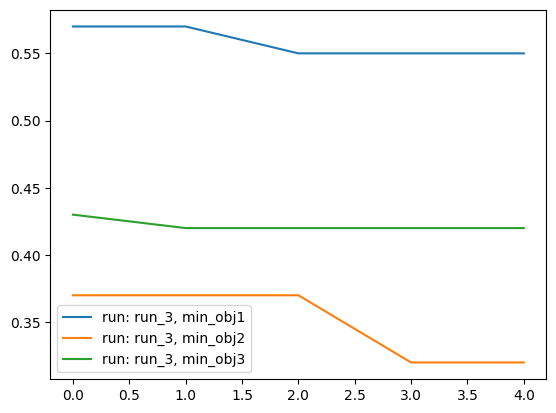

{0: {'min_obj1': 0.62, 'min_obj2': 0.49, 'min_obj3': 0.35, 'avg_obj1': 0.67625, 'avg_obj2': 0.5337500000000001, 'avg_obj3': 0.40499999999999997}, 1: {'min_obj1': 0.6, 'min_obj2': 0.49, 'min_obj3': 0.32, 'avg_obj1': 0.6733333333333333, 'avg_obj2': 0.54, 'avg_obj3': 0.4008333333333333}, 2: {'min_obj1': 0.58, 'min_obj2': 0.47, 'min_obj3': 0.32, 'avg_obj1': 0.6795, 'avg_obj2': 0.525, 'avg_obj3': 0.39849999999999997}, 3: {'min_obj1': 0.58, 'min_obj2': 0.45, 'min_obj3': 0.31, 'avg_obj1': 0.6647058823529413, 'avg_obj2': 0.5247058823529411, 'avg_obj3': 0.398235294117647}, 4: {'min_obj1': 0.53, 'min_obj2': 0.45, 'min_obj3': 0.28, 'avg_obj1': 0.6677777777777778, 'avg_obj2': 0.5161111111111112, 'avg_obj3': 0.385}}


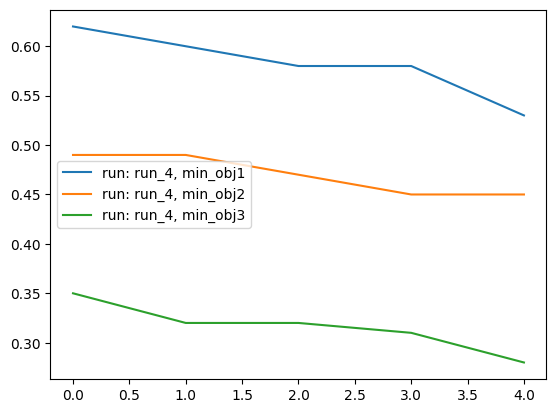

{0: {'min_obj1': 0.61, 'min_obj2': 0.55, 'min_obj3': 0.3, 'avg_obj1': 0.68375, 'avg_obj2': 0.6, 'avg_obj3': 0.35875}, 1: {'min_obj1': 0.61, 'min_obj2': 0.55, 'min_obj3': 0.27, 'avg_obj1': 0.6666666666666666, 'avg_obj2': 0.5988888888888888, 'avg_obj3': 0.35888888888888887}, 2: {'min_obj1': 0.61, 'min_obj2': 0.53, 'min_obj3': 0.27, 'avg_obj1': 0.68125, 'avg_obj2': 0.57, 'avg_obj3': 0.34625}, 3: {'min_obj1': 0.59, 'min_obj2': 0.53, 'min_obj3': 0.27, 'avg_obj1': 0.6522222222222223, 'avg_obj2': 0.5855555555555555, 'avg_obj3': 0.36000000000000004}, 4: {'min_obj1': 0.55, 'min_obj2': 0.51, 'min_obj3': 0.27, 'avg_obj1': 0.6342857142857143, 'avg_obj2': 0.5742857142857142, 'avg_obj3': 0.29857142857142854}}


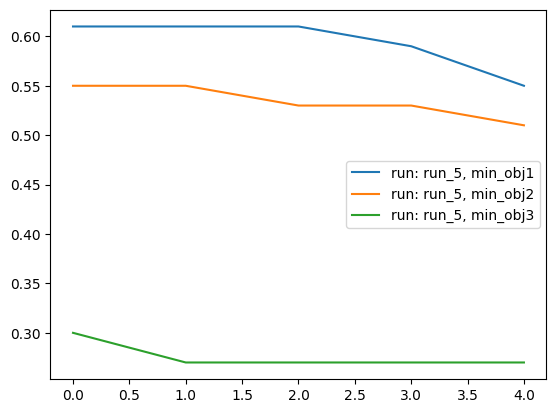

{0: {'min_obj1': 0.62, 'min_obj2': 0.6, 'min_obj3': 0.38, 'avg_obj1': 0.6883333333333334, 'avg_obj2': 0.6316666666666667, 'avg_obj3': 0.42333333333333334}, 1: {'min_obj1': 0.62, 'min_obj2': 0.59, 'min_obj3': 0.35, 'avg_obj1': 0.6875, 'avg_obj2': 0.635, 'avg_obj3': 0.4075}, 2: {'min_obj1': 0.62, 'min_obj2': 0.54, 'min_obj3': 0.34, 'avg_obj1': 0.687, 'avg_obj2': 0.618, 'avg_obj3': 0.40700000000000003}, 3: {'min_obj1': 0.62, 'min_obj2': 0.54, 'min_obj3': 0.34, 'avg_obj1': 0.6892307692307692, 'avg_obj2': 0.6084615384615385, 'avg_obj3': 0.4046153846153846}, 4: {'min_obj1': 0.61, 'min_obj2': 0.53, 'min_obj3': 0.3, 'avg_obj1': 0.6976470588235294, 'avg_obj2': 0.5994117647058823, 'avg_obj3': 0.39176470588235296}}


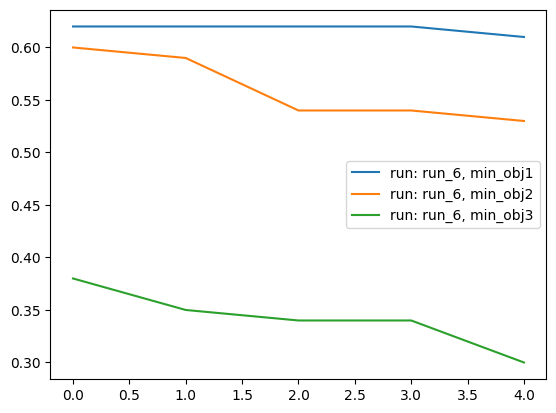

{0: {'min_obj1': 0.63, 'min_obj2': 0.56, 'min_obj3': 0.24, 'avg_obj1': 0.71, 'avg_obj2': 0.5740000000000001, 'avg_obj3': 0.29}, 1: {'min_obj1': 0.63, 'min_obj2': 0.52, 'min_obj3': 0.23, 'avg_obj1': 0.73, 'avg_obj2': 0.5575, 'avg_obj3': 0.28125}, 2: {'min_obj1': 0.62, 'min_obj2': 0.47, 'min_obj3': 0.23, 'avg_obj1': 0.7141666666666667, 'avg_obj2': 0.5499999999999999, 'avg_obj3': 0.3066666666666667}, 3: {'min_obj1': 0.62, 'min_obj2': 0.47, 'min_obj3': 0.23, 'avg_obj1': 0.712, 'avg_obj2': 0.537, 'avg_obj3': 0.294}, 4: {'min_obj1': 0.62, 'min_obj2': 0.47, 'min_obj3': 0.23, 'avg_obj1': 0.7183333333333333, 'avg_obj2': 0.5241666666666667, 'avg_obj3': 0.2866666666666667}}


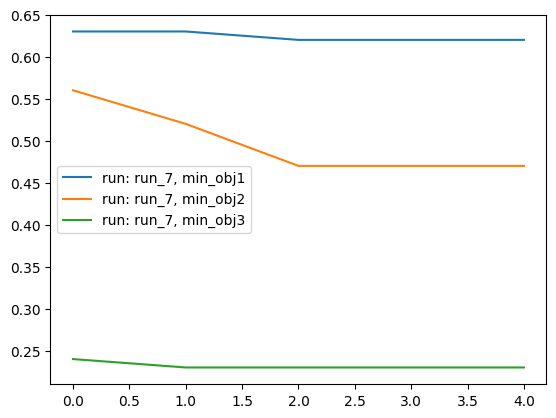

{0: {'min_obj1': 0.64, 'min_obj2': 0.64, 'min_obj3': 0.24, 'avg_obj1': 0.73, 'avg_obj2': 0.70125, 'avg_obj3': 0.29625}, 1: {'min_obj1': 0.64, 'min_obj2': 0.64, 'min_obj3': 0.22, 'avg_obj1': 0.743, 'avg_obj2': 0.688, 'avg_obj3': 0.273}, 2: {'min_obj1': 0.64, 'min_obj2': 0.64, 'min_obj3': 0.19, 'avg_obj1': 0.73, 'avg_obj2': 0.6872727272727273, 'avg_obj3': 0.25636363636363635}, 3: {'min_obj1': 0.63, 'min_obj2': 0.63, 'min_obj3': 0.19, 'avg_obj1': 0.7212500000000001, 'avg_obj2': 0.68375, 'avg_obj3': 0.259375}, 4: {'min_obj1': 0.6, 'min_obj2': 0.63, 'min_obj3': 0.19, 'avg_obj1': 0.7000000000000001, 'avg_obj2': 0.6835714285714286, 'avg_obj3': 0.2671428571428572}}


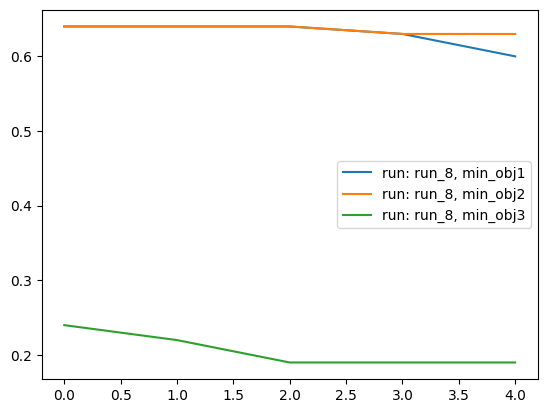

{0: {'min_obj1': 0.7, 'min_obj2': 0.57, 'min_obj3': 0.22, 'avg_obj1': 0.75125, 'avg_obj2': 0.60125, 'avg_obj3': 0.275}, 1: {'min_obj1': 0.7, 'min_obj2': 0.57, 'min_obj3': 0.22, 'avg_obj1': 0.7418181818181818, 'avg_obj2': 0.5990909090909091, 'avg_obj3': 0.2872727272727273}, 2: {'min_obj1': 0.68, 'min_obj2': 0.56, 'min_obj3': 0.22, 'avg_obj1': 0.7341176470588235, 'avg_obj2': 0.6029411764705882, 'avg_obj3': 0.28647058823529414}, 3: {'min_obj1': 0.67, 'min_obj2': 0.54, 'min_obj3': 0.22, 'avg_obj1': 0.7157142857142856, 'avg_obj2': 0.6114285714285714, 'avg_obj3': 0.2864285714285714}, 4: {'min_obj1': 0.66, 'min_obj2': 0.54, 'min_obj3': 0.2, 'avg_obj1': 0.7125, 'avg_obj2': 0.61, 'avg_obj3': 0.28}}


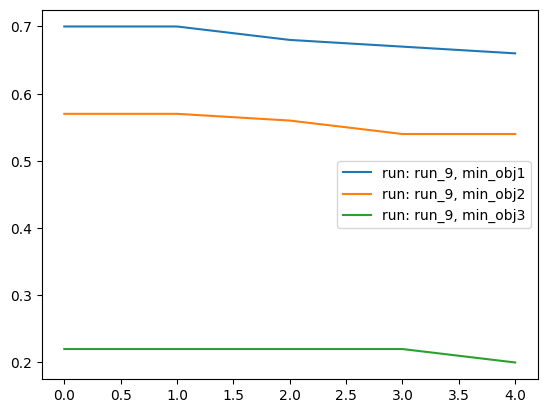

In [5]:
import matplotlib.pyplot as plt

def visualize(data_for_visualization: dict):
    for run, run_values in data_for_visualization.items():
        gens = []
        min_obj1_values = []
        min_obj2_values = []
        min_obj3_values = []
        print(run_values)
        for gen, gen_values in run_values.items():
            gens.append(gen)
            min_obj1 = gen_values["min_obj1"]
            min_obj2 = gen_values["min_obj2"]
            min_obj3 = gen_values["min_obj3"]

            min_obj1_values.append(min_obj1)
            min_obj2_values.append(min_obj2)
            min_obj3_values.append(min_obj3)

        plt.plot(gens, min_obj1_values, label=f"run: {run}, min_obj1")
        plt.plot(gens, min_obj2_values, label=f"run: {run}, min_obj2")
        plt.plot(gens, min_obj3_values, label=f"run: {run}, min_obj3")
        plt.legend()
        plt.show()

visualize(visualization_data)

{0: {'min_obj1': 0.48, 'min_obj2': 0.17, 'min_obj3': 0.69, 'avg_obj1': 0.5690000000000001, 'avg_obj2': 0.23900000000000002, 'avg_obj3': 0.771}, 1: {'min_obj1': 0.48, 'min_obj2': 0.17, 'min_obj3': 0.69, 'avg_obj1': 0.575, 'avg_obj2': 0.23333333333333334, 'avg_obj3': 0.7672222222222222}, 2: {'min_obj1': 0.47, 'min_obj2': 0.17, 'min_obj3': 0.69, 'avg_obj1': 0.5542857142857143, 'avg_obj2': 0.23666666666666666, 'avg_obj3': 0.7685714285714286}, 3: {'min_obj1': 0.44, 'min_obj2': 0.17, 'min_obj3': 0.69, 'avg_obj1': 0.5289473684210527, 'avg_obj2': 0.24105263157894738, 'avg_obj3': 0.741578947368421}, 4: {'min_obj1': 0.34, 'min_obj2': 0.15, 'min_obj3': 0.68, 'avg_obj1': 0.5178260869565218, 'avg_obj2': 0.24173913043478262, 'avg_obj3': 0.7404347826086957}}


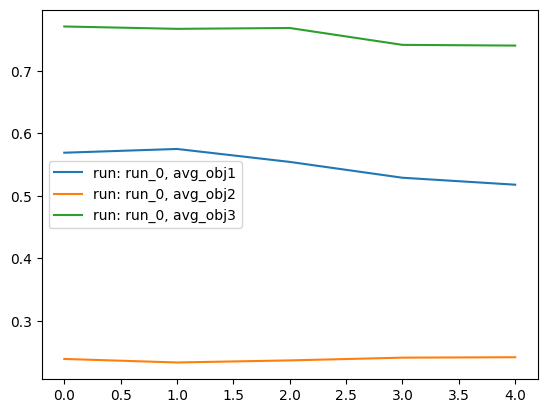

{0: {'min_obj1': 0.5, 'min_obj2': 0.37, 'min_obj3': 0.58, 'avg_obj1': 0.5790909090909091, 'avg_obj2': 0.4227272727272728, 'avg_obj3': 0.6645454545454546}, 1: {'min_obj1': 0.5, 'min_obj2': 0.34, 'min_obj3': 0.58, 'avg_obj1': 0.5821052631578948, 'avg_obj2': 0.4142105263157895, 'avg_obj3': 0.6552631578947368}, 2: {'min_obj1': 0.5, 'min_obj2': 0.34, 'min_obj3': 0.58, 'avg_obj1': 0.5736363636363637, 'avg_obj2': 0.4163636363636364, 'avg_obj3': 0.6554545454545454}, 3: {'min_obj1': 0.48, 'min_obj2': 0.34, 'min_obj3': 0.57, 'avg_obj1': 0.5735714285714285, 'avg_obj2': 0.41571428571428576, 'avg_obj3': 0.6542857142857142}, 4: {'min_obj1': 0.48, 'min_obj2': 0.34, 'min_obj3': 0.57, 'avg_obj1': 0.5720689655172414, 'avg_obj2': 0.406551724137931, 'avg_obj3': 0.6448275862068965}}


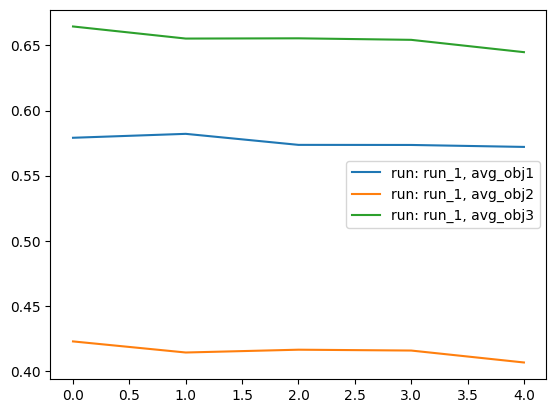

{0: {'min_obj1': 0.53, 'min_obj2': 0.28, 'min_obj3': 0.51, 'avg_obj1': 0.595, 'avg_obj2': 0.37125, 'avg_obj3': 0.63125}, 1: {'min_obj1': 0.53, 'min_obj2': 0.28, 'min_obj3': 0.48, 'avg_obj1': 0.6157142857142858, 'avg_obj2': 0.36428571428571427, 'avg_obj3': 0.6378571428571428}, 2: {'min_obj1': 0.52, 'min_obj2': 0.26, 'min_obj3': 0.48, 'avg_obj1': 0.6122727272727273, 'avg_obj2': 0.3709090909090909, 'avg_obj3': 0.615}, 3: {'min_obj1': 0.51, 'min_obj2': 0.22, 'min_obj3': 0.46, 'avg_obj1': 0.6062962962962963, 'avg_obj2': 0.36333333333333334, 'avg_obj3': 0.6251851851851852}, 4: {'min_obj1': 0.47, 'min_obj2': 0.22, 'min_obj3': 0.46, 'avg_obj1': 0.6086666666666667, 'avg_obj2': 0.3496666666666667, 'avg_obj3': 0.6329999999999999}}


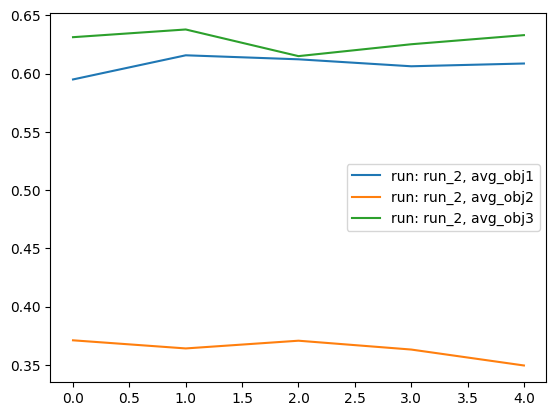

{0: {'min_obj1': 0.57, 'min_obj2': 0.37, 'min_obj3': 0.43, 'avg_obj1': 0.6529999999999999, 'avg_obj2': 0.45999999999999996, 'avg_obj3': 0.5589999999999999}, 1: {'min_obj1': 0.57, 'min_obj2': 0.37, 'min_obj3': 0.42, 'avg_obj1': 0.651, 'avg_obj2': 0.4645, 'avg_obj3': 0.5505}, 2: {'min_obj1': 0.55, 'min_obj2': 0.37, 'min_obj3': 0.42, 'avg_obj1': 0.643125, 'avg_obj2': 0.455, 'avg_obj3': 0.576875}, 3: {'min_obj1': 0.55, 'min_obj2': 0.32, 'min_obj3': 0.42, 'avg_obj1': 0.642, 'avg_obj2': 0.445, 'avg_obj3': 0.5525}, 4: {'min_obj1': 0.55, 'min_obj2': 0.32, 'min_obj3': 0.42, 'avg_obj1': 0.648125, 'avg_obj2': 0.424375, 'avg_obj3': 0.55875}}


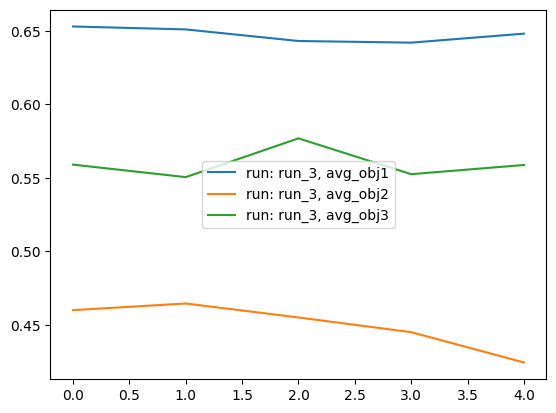

{0: {'min_obj1': 0.62, 'min_obj2': 0.49, 'min_obj3': 0.35, 'avg_obj1': 0.67625, 'avg_obj2': 0.5337500000000001, 'avg_obj3': 0.40499999999999997}, 1: {'min_obj1': 0.6, 'min_obj2': 0.49, 'min_obj3': 0.32, 'avg_obj1': 0.6733333333333333, 'avg_obj2': 0.54, 'avg_obj3': 0.4008333333333333}, 2: {'min_obj1': 0.58, 'min_obj2': 0.47, 'min_obj3': 0.32, 'avg_obj1': 0.6795, 'avg_obj2': 0.525, 'avg_obj3': 0.39849999999999997}, 3: {'min_obj1': 0.58, 'min_obj2': 0.45, 'min_obj3': 0.31, 'avg_obj1': 0.6647058823529413, 'avg_obj2': 0.5247058823529411, 'avg_obj3': 0.398235294117647}, 4: {'min_obj1': 0.53, 'min_obj2': 0.45, 'min_obj3': 0.28, 'avg_obj1': 0.6677777777777778, 'avg_obj2': 0.5161111111111112, 'avg_obj3': 0.385}}


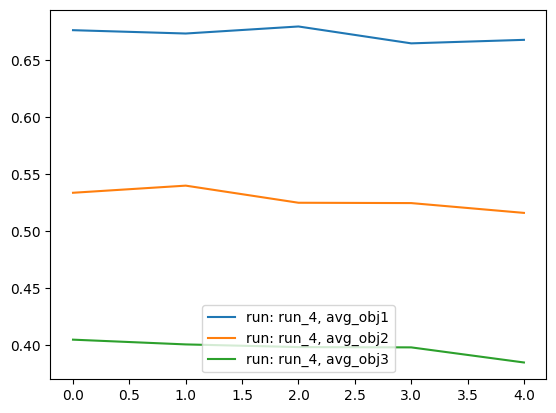

{0: {'min_obj1': 0.61, 'min_obj2': 0.55, 'min_obj3': 0.3, 'avg_obj1': 0.68375, 'avg_obj2': 0.6, 'avg_obj3': 0.35875}, 1: {'min_obj1': 0.61, 'min_obj2': 0.55, 'min_obj3': 0.27, 'avg_obj1': 0.6666666666666666, 'avg_obj2': 0.5988888888888888, 'avg_obj3': 0.35888888888888887}, 2: {'min_obj1': 0.61, 'min_obj2': 0.53, 'min_obj3': 0.27, 'avg_obj1': 0.68125, 'avg_obj2': 0.57, 'avg_obj3': 0.34625}, 3: {'min_obj1': 0.59, 'min_obj2': 0.53, 'min_obj3': 0.27, 'avg_obj1': 0.6522222222222223, 'avg_obj2': 0.5855555555555555, 'avg_obj3': 0.36000000000000004}, 4: {'min_obj1': 0.55, 'min_obj2': 0.51, 'min_obj3': 0.27, 'avg_obj1': 0.6342857142857143, 'avg_obj2': 0.5742857142857142, 'avg_obj3': 0.29857142857142854}}


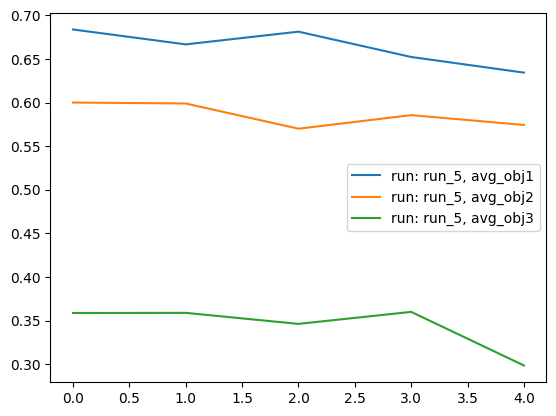

{0: {'min_obj1': 0.62, 'min_obj2': 0.6, 'min_obj3': 0.38, 'avg_obj1': 0.6883333333333334, 'avg_obj2': 0.6316666666666667, 'avg_obj3': 0.42333333333333334}, 1: {'min_obj1': 0.62, 'min_obj2': 0.59, 'min_obj3': 0.35, 'avg_obj1': 0.6875, 'avg_obj2': 0.635, 'avg_obj3': 0.4075}, 2: {'min_obj1': 0.62, 'min_obj2': 0.54, 'min_obj3': 0.34, 'avg_obj1': 0.687, 'avg_obj2': 0.618, 'avg_obj3': 0.40700000000000003}, 3: {'min_obj1': 0.62, 'min_obj2': 0.54, 'min_obj3': 0.34, 'avg_obj1': 0.6892307692307692, 'avg_obj2': 0.6084615384615385, 'avg_obj3': 0.4046153846153846}, 4: {'min_obj1': 0.61, 'min_obj2': 0.53, 'min_obj3': 0.3, 'avg_obj1': 0.6976470588235294, 'avg_obj2': 0.5994117647058823, 'avg_obj3': 0.39176470588235296}}


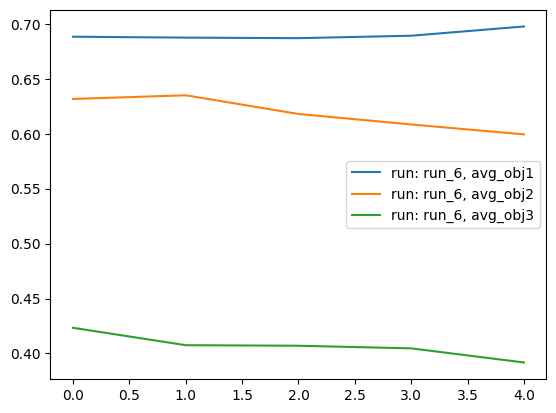

{0: {'min_obj1': 0.63, 'min_obj2': 0.56, 'min_obj3': 0.24, 'avg_obj1': 0.71, 'avg_obj2': 0.5740000000000001, 'avg_obj3': 0.29}, 1: {'min_obj1': 0.63, 'min_obj2': 0.52, 'min_obj3': 0.23, 'avg_obj1': 0.73, 'avg_obj2': 0.5575, 'avg_obj3': 0.28125}, 2: {'min_obj1': 0.62, 'min_obj2': 0.47, 'min_obj3': 0.23, 'avg_obj1': 0.7141666666666667, 'avg_obj2': 0.5499999999999999, 'avg_obj3': 0.3066666666666667}, 3: {'min_obj1': 0.62, 'min_obj2': 0.47, 'min_obj3': 0.23, 'avg_obj1': 0.712, 'avg_obj2': 0.537, 'avg_obj3': 0.294}, 4: {'min_obj1': 0.62, 'min_obj2': 0.47, 'min_obj3': 0.23, 'avg_obj1': 0.7183333333333333, 'avg_obj2': 0.5241666666666667, 'avg_obj3': 0.2866666666666667}}


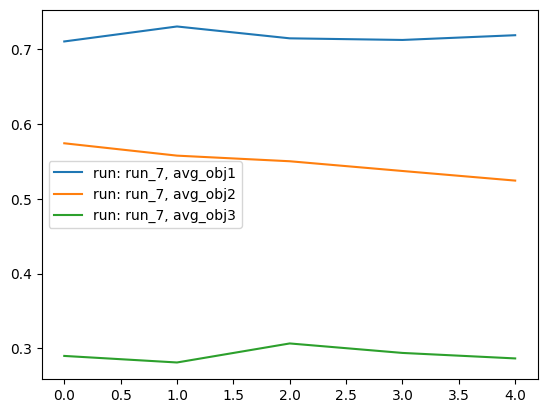

{0: {'min_obj1': 0.64, 'min_obj2': 0.64, 'min_obj3': 0.24, 'avg_obj1': 0.73, 'avg_obj2': 0.70125, 'avg_obj3': 0.29625}, 1: {'min_obj1': 0.64, 'min_obj2': 0.64, 'min_obj3': 0.22, 'avg_obj1': 0.743, 'avg_obj2': 0.688, 'avg_obj3': 0.273}, 2: {'min_obj1': 0.64, 'min_obj2': 0.64, 'min_obj3': 0.19, 'avg_obj1': 0.73, 'avg_obj2': 0.6872727272727273, 'avg_obj3': 0.25636363636363635}, 3: {'min_obj1': 0.63, 'min_obj2': 0.63, 'min_obj3': 0.19, 'avg_obj1': 0.7212500000000001, 'avg_obj2': 0.68375, 'avg_obj3': 0.259375}, 4: {'min_obj1': 0.6, 'min_obj2': 0.63, 'min_obj3': 0.19, 'avg_obj1': 0.7000000000000001, 'avg_obj2': 0.6835714285714286, 'avg_obj3': 0.2671428571428572}}


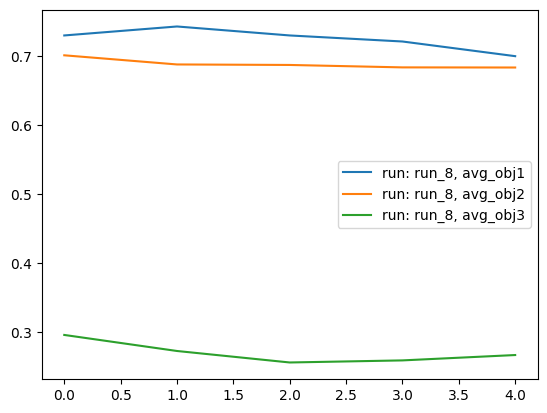

{0: {'min_obj1': 0.7, 'min_obj2': 0.57, 'min_obj3': 0.22, 'avg_obj1': 0.75125, 'avg_obj2': 0.60125, 'avg_obj3': 0.275}, 1: {'min_obj1': 0.7, 'min_obj2': 0.57, 'min_obj3': 0.22, 'avg_obj1': 0.7418181818181818, 'avg_obj2': 0.5990909090909091, 'avg_obj3': 0.2872727272727273}, 2: {'min_obj1': 0.68, 'min_obj2': 0.56, 'min_obj3': 0.22, 'avg_obj1': 0.7341176470588235, 'avg_obj2': 0.6029411764705882, 'avg_obj3': 0.28647058823529414}, 3: {'min_obj1': 0.67, 'min_obj2': 0.54, 'min_obj3': 0.22, 'avg_obj1': 0.7157142857142856, 'avg_obj2': 0.6114285714285714, 'avg_obj3': 0.2864285714285714}, 4: {'min_obj1': 0.66, 'min_obj2': 0.54, 'min_obj3': 0.2, 'avg_obj1': 0.7125, 'avg_obj2': 0.61, 'avg_obj3': 0.28}}


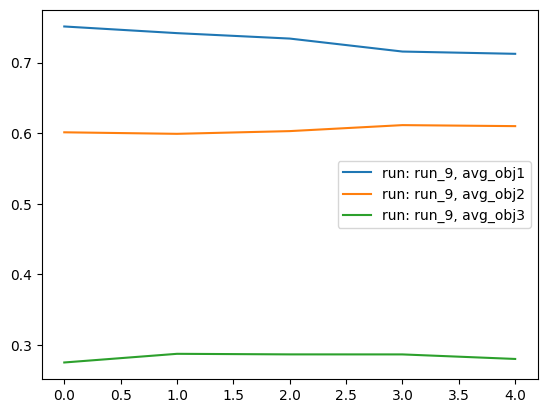

In [6]:
import matplotlib.pyplot as plt

def visualize(data_for_visualization: dict):
    for run, run_values in data_for_visualization.items():
        gens = []
        avg_obj1_values = []
        avg_obj2_values = []
        avg_obj3_values = []
        print(run_values)
        for gen, gen_values in run_values.items():
            gens.append(gen)
            avg_obj1 = gen_values["avg_obj1"]
            avg_obj2 = gen_values["avg_obj2"]
            avg_obj3 = gen_values["avg_obj3"]

            avg_obj1_values.append(avg_obj1)
            avg_obj2_values.append(avg_obj2)
            avg_obj3_values.append(avg_obj3)

        plt.plot(gens, avg_obj1_values, label=f"run: {run}, avg_obj1")
        plt.plot(gens, avg_obj2_values, label=f"run: {run}, avg_obj2")
        plt.plot(gens, avg_obj3_values, label=f"run: {run}, avg_obj3")
        plt.legend()
        plt.show()

visualize(visualization_data)